In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt
from scipy import stats
from tqdm.notebook import tqdm as tqdm_notebook
import random
from copy import deepcopy

### Задача 1. CUPED (2.5 балла)

Cгенерируем выборку из $1000$ сэмплов экспоненциального распределения - это будут значения нашей метрики для $1000$ пользователей

In [2]:
control_before = stats.expon(scale=1000).rvs(1000)

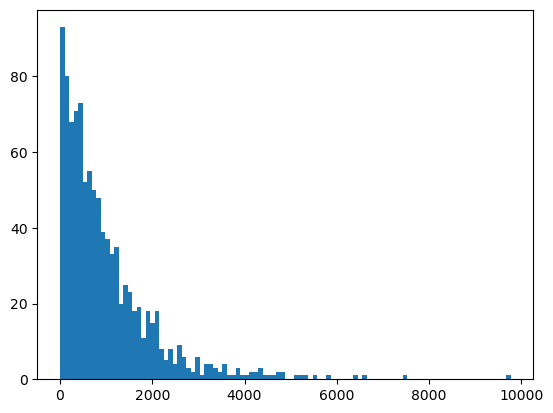

In [3]:
plt.hist(control_before, bins=100)
plt.show()

Предположим, что при наблюдении метрики в дальнейшем добавляется какой-то нормальный шум

In [4]:
control = control_before + stats.norm(loc=0, scale=100).rvs(1000)

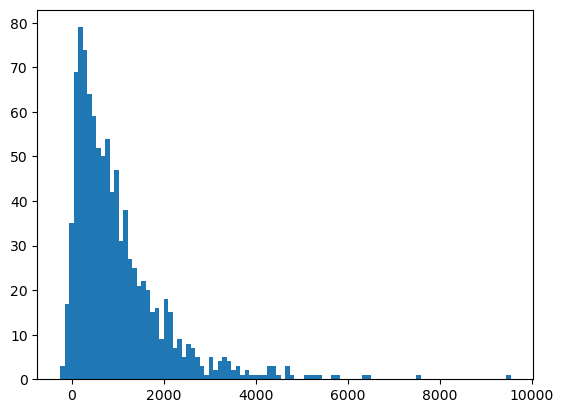

In [5]:
plt.hist(control, bins=100)
plt.show()

Теперь построим доверительный интервал для среднего значения нашей метрики и посмотрим, появилась ли стат значимая разница. Проведем такой эксперимент $10000$ раз

In [6]:
stats.norm(loc=control.mean(), scale=control.std() / np.sqrt(len(control))).ppf(
    [0.025, 0.975]
)

array([ 930.54996981, 1059.83192728])

In [7]:
bad_cnt = 0

N = 10000
for i in tqdm_notebook(range(N)):
    control_before = stats.expon(scale=1000).rvs(1000)
    control = control_before + stats.norm(loc=0, scale=100).rvs(1000)
    left_bound, right_bound = stats.norm(
        loc=control.mean(), scale=control.std() / np.sqrt(len(control))
    ).ppf([0.025, 0.975])

    if left_bound > 1000 or right_bound < 1000:
        bad_cnt += 1

print(f"Стат значимая разница есть в {round(bad_cnt / N, 4) * 100}% случаев;")

  0%|          | 0/10000 [00:00<?, ?it/s]

Стат значимая разница есть в 5.16% случаев;


Как мы видим такой тест ошибается в около $5$% случаев, так как находит разницу в среднем. Ваша задача построить CUPED-метрику основываясь на данной метрике и провести аналогичный тест

In [8]:
bad_cnt = 0

N = 10000
for i in tqdm_notebook(range(N)):
    control_before = stats.expon(scale=1000).rvs(1000)
    control = control_before + stats.norm(loc=0, scale=100).rvs(1000)

    # Расчет CUPED метрики
    theta = np.cov(control, control_before)[0, 1] / np.var(control_before)
    cuped_metric = control - theta * (control_before - np.mean(control_before))

    # Расчет среднего и стандартного отклонения для CUPED метрики
    mean = np.mean(cuped_metric)
    std = np.std(cuped_metric, ddof=1) / np.sqrt(len(cuped_metric))  # SE

    left_bound, right_bound = stats.norm(loc=mean, scale=std).ppf([0.025, 0.975])

    if left_bound > 1000 or right_bound < 1000:
        bad_cnt += 1

print(f"Стат значимая разница есть в  {round(bad_cnt / N, 4) * 100}% случаев;")

  0%|          | 0/10000 [00:00<?, ?it/s]

Стат значимая разница есть в  84.53% случаев;


Результат должен получиться не очень хороший. Давайте теперь сделаем иначе: сгенерируем выборку из $10000$ значений, а затем выберем $2$ группы по $1000$ юзеров, которые будут нашими группами для теста. Опять добавим шум в обе группы аналогично тому, что показано в первом примере с теми же параметрами. Ваша задача вписать CUPED метрики используя знание обо всех $10000$ юзерах.

In [9]:
bad_cnt = 0

N = 10000
for i in tqdm_notebook(range(N)):
    control_before_full = stats.expon(scale=1000).rvs(1000 * 10)
    samples_in_ab = 2000
    indexes_to_take_a = np.random.choice(
        range(samples_in_ab), samples_in_ab // 2, False
    )
    indexes_to_take_b = [x for x in range(samples_in_ab) if x not in indexes_to_take_a]

    control_before_a = control_before_full[indexes_to_take_a]
    control_before_b = control_before_full[indexes_to_take_b]

    control_after_a = control_before_a + stats.norm(loc=0, scale=100).rvs(
        samples_in_ab // 2
    )
    control_after_b = control_before_b + stats.norm(loc=0, scale=100).rvs(
        samples_in_ab // 2
    )

    # Вычисление коэффициента коррекции на основе всех пользователей
    theta = np.cov(control_before_full, control_before_full + stats.norm(loc=0, scale=100).rvs(10000))[0, 1] / np.var(control_before_full)

    # Применение коррекции CUPED
    control_cup_a = control_after_a - theta * (control_before_a - np.mean(control_before_full))
    control_cup_b = control_after_b - theta * (control_before_b - np.mean(control_before_full))

    if stats.kstest(control_cup_a, control_cup_b).pvalue < 0.05:
        bad_cnt += 1

print(f"Стат значимая разница есть в  {round(bad_cnt / N, 4) * 100}% случаев;")

  0%|          | 0/10000 [00:00<?, ?it/s]

Стат значимая разница есть в  4.46% случаев;


Результат получился уже совсем другой. Опишите свои мысли по поводу того, из-за чего возникает такая разница:



Так как мы учли больше данных, ибо учли знания о 10к пользаков, то результат получился лучше

Далее проделаем такой же эксперимент при наличии реального смещения среднего значения и посмотрим на результаты с CUPED и без.

In [10]:
bad_cnt = 0
bad_cnt_cuped = 0

N = 10000
for i in tqdm_notebook(range(N)):
    control_before_full = stats.expon(scale=1000).rvs(1000 * 10)
    samples_in_ab = 2000
    indexes_to_take_a = np.random.choice(
        range(samples_in_ab), samples_in_ab // 2, False
    )
    indexes_to_take_b = [x for x in range(samples_in_ab) if x not in indexes_to_take_a]

    control_before_a = control_before_full[indexes_to_take_a]
    control_before_b = control_before_full[indexes_to_take_b]

    control_after_a = control_before_a + stats.norm(loc=0, scale=100).rvs(
        samples_in_ab // 2
    )
    control_after_b = control_before_b + stats.norm(loc=10, scale=100).rvs(
        samples_in_ab // 2
    )

    # Расчет CUPED
    theta = np.cov(control_before_full, control_before_full)[0, 1] / np.var(control_before_full)
    control_cup_a = control_after_a - theta * (control_before_a - np.mean(control_before_full))
    control_cup_b = control_after_b - theta * (control_before_b - np.mean(control_before_full))

    if stats.kstest(control_after_a, control_after_b).pvalue < 0.05:
        bad_cnt += 1

    if stats.kstest(control_cup_a, control_cup_b).pvalue < 0.05:
        bad_cnt_cuped += 1

print(
    f"Стат значимая разница есть в  {round(bad_cnt / N, 4) * 100}% случаев; при использовании CUPED -- в {round(bad_cnt_cuped / N, 4) * 100}% случаев"
)

  0%|          | 0/10000 [00:00<?, ?it/s]

Стат значимая разница есть в  5.8999999999999995% случаев; при использовании CUPED -- в 48.0% случаев


### Задача 2. Методы снижения дисперсии (2.5 балла)

В этой части задания вам нужно применить методы снижения дисперсии с лекций, чтобы провести более точные тесты по данным из файла.

Данные представляют собой значение какой-то метрики для трех возрастных групп пользователей. Столбец group отвечает за группу, в которой находятся пользователи: 
- `None` - пользователь не участвует в АБ тесте, 
- `*_before_i` - соответствующая группа до начала теста, 
- `*_after_i` - группа после начала эксперимента

Чем больше i, тем позже было сделано наблюдение. 

Cчитайте, что юзеры всегда идут в одном порядке в группах. То есть `data[data.group == 'control_before_i']`
дает юзеров в той же последовательности, что `data[data.group == 'control_after_i']` для всех i.  Аналогичное верно для тритмента.


#### Задание
1. Напишите тест Стьюдента самостоятельно - то есть вы должны сами вычислить тестовую статистику, а затем используя квантильную функцию определить p-value. Квантили можно брать из готовых библиотек.

2. Реализуйте пост-стратификацию и CUPED. 

3. Проведите тесты между `control_before_i` и `treatment_before_i` снчала без применения пост-стратификации и CUPED, а затем с ними. Без применения каких-либо методов такой тест покажет p-value около $0.05$ только при i == 5. Ваша задача применить методы уменьшения дисперсии, чтобы с помощью теста Стьюдента можно было обнаружить отличие на уровне значимости $0.05$

4. Опишите свои результаты.

Напишем t-test

In [11]:
# Вычисление стратифицированного среднего
def calculate_stratified_mean(dataframe, group_weights, column):
    # Вычисляем средние значения для каждой страты
    stratified_means = dataframe.groupby('age')[column].mean()
    # Возвращаем взвешенное среднее
    return np.sum(stratified_means * group_weights)

# Вычисление стратифицированной дисперсии
def calculate_stratified_variance(dataframe, group_weights, column):
    # Вычисляем дисперсии для каждой страты
    stratified_variances = dataframe.groupby('age')[column].var()
    # Возвращаем взвешенную дисперсию
    return np.sum(stratified_variances * group_weights)

# Проведение стратифицированного t-теста
def perform_stratified_t_test(group_a, group_b, group_weights, column):
    # Вычисляем стратифицированные средние и дисперсии для каждой группы
    mean_a = calculate_stratified_mean(group_a, group_weights, column)
    mean_b = calculate_stratified_mean(group_b, group_weights, column)
    variance_a = calculate_stratified_variance(group_a, group_weights, column)
    variance_b = calculate_stratified_variance(group_b, group_weights, column)
    
    # Вычисляем разницу средних и стандартную ошибку разности
    mean_difference = mean_b - mean_a
    standard_error = np.sqrt(variance_a / len(group_a) + variance_b / len(group_b))
    
    # Вычисляем t-статистику и p-value
    t_statistic = mean_difference / standard_error
    p_value = 2 * (1 - stats.norm.cdf(abs(t_statistic)))
    return p_value


In [12]:
data = pd.read_csv("data_ab.csv")
data

,age,metric,group
0,young,11309.036916,treatment_before
1,young,8496.554679,control_before
2,young,11891.862586,control_before
3,young,9229.445011,treatment_before
4,young,10410.961279,control_before
...,...,...,...
99995,old,7890.224384,treatment_after_5
99996,old,8165.046263,treatment_after_5
99997,old,10034.632118,treatment_after_5
99998,old,7564.445251,treatment_after_5


In [13]:
data.groupby('group')['metric'].mean()

group
control_after_1      11541.496271
control_after_2      11535.831276
control_after_3      11536.482627
control_after_4      11535.155377
control_after_5      11536.232113
control_before       11544.622805
treatment_after_1    11570.246710
treatment_after_2    11596.628437
treatment_after_3    11623.288837
treatment_after_4    11648.326533
treatment_after_5    11677.578923
treatment_before     11547.880757
Name: metric, dtype: float64

In [14]:
#обработаем данные

data_no_cuped = data

data_no_cuped['group'] = data_no_cuped['group'].replace('control_after_1', 'control')
data_no_cuped['group'] = data_no_cuped['group'].replace('control_after_2', 'control')
data_no_cuped['group'] = data_no_cuped['group'].replace('control_after_3', 'control')
data_no_cuped['group'] = data_no_cuped['group'].replace('control_after_4', 'control')
data_no_cuped['group'] = data_no_cuped['group'].replace('control_after_5', 'control')

data_no_cuped['group'] = data_no_cuped['group'].replace('treatment_after_1', 'treatment')
data_no_cuped['group'] = data_no_cuped['group'].replace('treatment_after_2', 'treatment')
data_no_cuped['group'] = data_no_cuped['group'].replace('treatment_after_3', 'treatment')
data_no_cuped['group'] = data_no_cuped['group'].replace('treatment_after_4', 'treatment')
data_no_cuped['group'] = data_no_cuped['group'].replace('treatment_after_5', 'treatment')


data_no_cuped = data_no_cuped.query("group not in ['treatment_before', 'control_before']")
data_no_cuped = data_no_cuped[~data_no_cuped['group'].isna()]

data_no_cuped.groupby('group')['metric'].mean()


group
control      11537.039533
treatment    11623.213888
Name: metric, dtype: float64

In [15]:
data_no_cuped = data_no_cuped[~data_no_cuped['group'].isna()]
data_no_cuped 

,age,metric,group
55000,young,8741.374306,control
55001,young,11818.071476,control
55002,young,10514.956374,control
55003,young,11581.819650,control
55004,young,9040.645542,control
...,...,...,...
99995,old,7890.224384,treatment
99996,old,8165.046263,treatment
99997,old,10034.632118,treatment
99998,old,7564.445251,treatment


In [16]:
data_no_cuped['metric'][data_no_cuped['group'] == 'control']

55000     8741.374306
55001    11818.071476
55002    10514.956374
55003    11581.819650
55004     9040.645542
             ...     
95495     7446.508586
95496     7349.510101
95497     8574.439844
95498     7520.131773
95499     9097.555265
Name: metric, Length: 22500, dtype: float64

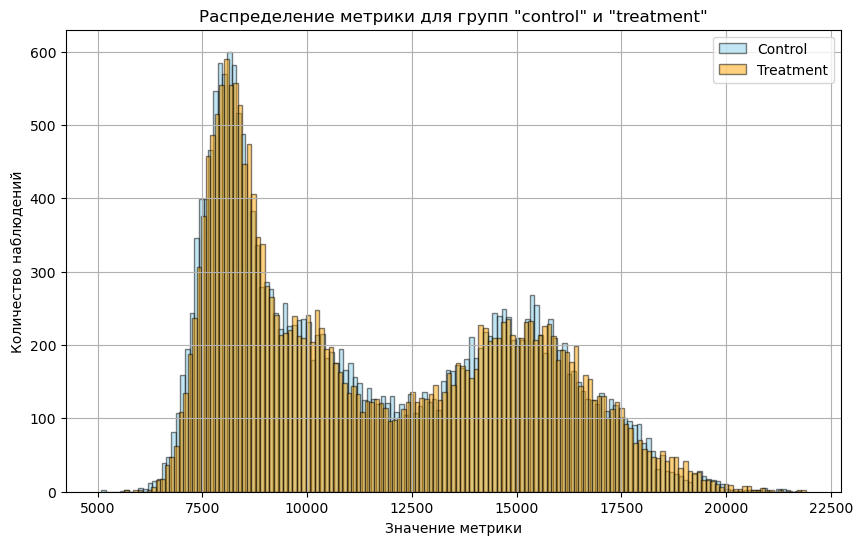

In [17]:
# Строим гистограмму для метрик обеих групп
plt.figure(figsize=(10, 6))

# Гистограмма для группы 'control'
plt.hist(data_no_cuped['metric'][data_no_cuped['group'] == 'control'], bins=150, color='skyblue', edgecolor='black', alpha=0.5, label='Control')

# Гистограмма для группы 'treatment'
plt.hist(data_no_cuped['metric'][data_no_cuped['group'] == 'treatment'], bins=150, color='orange', edgecolor='black', alpha=0.5, label='Treatment')

plt.title('Распределение метрики для групп "control" и "treatment"')
plt.xlabel('Значение метрики')
plt.ylabel('Количество наблюдений')
plt.legend()
plt.grid(True)
plt.show()

In [18]:
# Задаем уровень значимости
alpha = 0.05

# Сегментируем данные по группам
group_a = data_no_cuped[data_no_cuped['group'] == 'control']
group_b = data_no_cuped[data_no_cuped['group'] == 'treatment']

# Вычисляем веса для стратификации на основе возрастных групп
weights = group_a['age'].value_counts() / len(group_a)  # или любой другой способ задания весов

# Выполняем стратифицированный t-тест
p_value = perform_stratified_t_test(group_a, group_b, weights, 'metric')

# Выводим результаты теста
print(f"p-значение: {p_value}")
if p_value > alpha:
    print('Не отвергаем H0: различия между группами не являются статистически значимыми.')
else:
    print('Отвергаем H0: различия между группами статистически значимы.')

p-значение: 4.408078346784805e-10
Отвергаем H0: различия между группами статистически значимы.


А теперь посмотрим в разрезе каждой группы и возраста

In [19]:
data = pd.read_csv("data_ab.csv")
data = data[~data['group'].isna()]

In [20]:
def calculate_two_sample_t_test(sample1, sample2):
    # Вычисление среднего и стандартного отклонения для каждой выборки
    average1, average2 = np.mean(sample1), np.mean(sample2)
    std_dev1, std_dev2 = np.std(sample1, ddof=1), np.std(sample2, ddof=1)
    
    # Размер выборок
    n1, n2 = len(sample1), len(sample2)
    
    # Вычисление стандартной ошибки совокупности и t-значения
    pooled_se = np.sqrt(std_dev1**2/n1 + std_dev2**2/n2)
    t_value = (average1 - average2) / pooled_se
    
    # Расчет степеней свободы для двух выборок
    degrees_of_freedom = n1 + n2 - 2
    
    # Расчет двустороннего p-значения на основе t-значения и степеней свободы
    p_val = 2 * stats.t.sf(np.abs(t_value), degrees_of_freedom)
    
    return p_val

def calculate_theta(metric_after, metric_before):
    covariance = np.cov(metric_before, metric_after, ddof=1)[0, 1]
    variance = np.var(metric_before, ddof=1)
    theta = covariance / variance
    return theta

In [21]:
for i in range(1, 6):
    # Копирование данных для соответствующих групп
    df_tr_after = deepcopy(data[data['group'] == f"treatment_after_{i}"])
    df_cn_after = deepcopy(data[data['group'] == f"control_after_{i}"])
    df_tr_before = deepcopy(data[data['group'] == "treatment_before"])
    df_cn_before = deepcopy(data[data['group'] == "control_before"])

    # Вычисление коэффициента theta для CUPED
    theta = calculate_theta(
        np.concatenate([df_tr_after['metric'], df_cn_after['metric']]),
        np.concatenate([df_tr_before['metric'], df_cn_before['metric']])
    )

    # Исправленное применение CUPED
    # Убедитесь, что используете правильные средние для каждой из предварительных групп
    mean_tr_before = np.mean(df_tr_before['metric'])
    mean_cn_before = np.mean(df_cn_before['metric'])

    df_tr_after["cuped"] = (df_tr_after.metric.values - (theta * (df_tr_before.metric - np.mean(df_tr_before.metric))).values)
    df_cn_after['cuped'] = (df_cn_after.metric.values - (theta * (df_cn_before.metric - np.mean(df_cn_before.metric))).values)

    # Проверка на NaN после применения CUPED
    if df_tr_after['cuped'].isna().any() or df_cn_after['cuped'].isna().any():
        print(f"Group {i} contains NaNs after CUPED")
        # Обработайте строки с NaN, например, удалив их или заменив на некое значение
        df_tr_after['cuped'] = df_tr_after['cuped'].fillna(0)  # Пример обработки NaN
        df_cn_after['cuped'] = df_cn_after['cuped'].fillna(0)  # Пример обработки NaN

    # Вычисляем p-значения для обычных и скорректированных метрик
    p_def = calculate_two_sample_t_test(df_tr_after['metric'], df_cn_after['metric'])
    p_cuped = calculate_two_sample_t_test(df_tr_after['cuped'], df_cn_after['cuped'])

    # Подготовка данных и расчеты для стратификации
    full_df = pd.concat([df_tr_after, df_cn_after])
    weights = full_df['age'].value_counts(normalize=True)

    # Вывод результатов
    print(f"Группа {i} обычный p-value: {p_def}")
    print(f"Группа {i} CUPED p-value: {p_cuped}")
    print(f"Группа {i} Пост-стратификация p-value: {perform_stratified_t_test(df_tr_after, df_cn_after, weights, 'metric')}")
    print(f"Группа {i} Пост-стратификация + CUPED  p-value: {perform_stratified_t_test(df_tr_after, df_cn_after, weights, 'cuped')}", '\n')


Группа 1 обычный p-value: 0.6922472240558739
Группа 1 CUPED p-value: 1.1429368819064171e-11
Группа 1 Пост-стратификация p-value: 0.34267628378638393
Группа 1 Пост-стратификация + CUPED  p-value: 1.0798029137504273e-11 

Группа 2 обычный p-value: 0.4033494779637815
Группа 2 CUPED p-value: 7.821409980740228e-24
Группа 2 Пост-стратификация p-value: 0.04683766603710282
Группа 2 Пост-стратификация + CUPED  p-value: 0.0 

Группа 3 обычный p-value: 0.23366578647283134
Группа 3 CUPED p-value: 2.011067814361945e-31
Группа 3 Пост-стратификация p-value: 0.004915183248383359
Группа 3 Пост-стратификация + CUPED  p-value: 0.0 

Группа 4 обычный p-value: 0.12149348898963651
Группа 4 CUPED p-value: 2.1220169418696473e-39
Группа 4 Пост-стратификация p-value: 0.000286872471620514
Группа 4 Пост-стратификация + CUPED  p-value: 0.0 

Группа 5 обычный p-value: 0.053815168567470185
Группа 5 CUPED p-value: 1.0984566824143328e-48
Группа 5 Пост-стратификация p-value: 7.080597326458715e-06
Группа 5 Пост-стратифи

### Задача 3. Линеаризация + CUPED (2 балла)

1. В файле `duration_aa.csv` содержатся данные для АА-теста. Проверьте гипотезу о равенстве средних длительностей визита с помощью линеаризации, постройте распределение p-value.

2. Мы поменяли верстку нашего сайта и запустили АБ-тест, чтобы выяснить, увеличилась ли средняя продолжительность визита при новом дизайне. Результаты теста лежат в файле `duration_ab.csv`. С помощью линеаризованной метрики проверьте, есть ли разница в средней длительности визита между контрольной и тестовой группами.

3. Примените CUPED и снова проведите АБ-тест. Что произошло с p-value? Почему?

В каждом пункте необходимо визуализировать распределение p-value и сонаправленность линеаризованной разности метрик и разности ratio-метрик.

In [22]:
data = pd.read_csv("duration_aa.csv")
data

,Unnamed: 0,user_id,group,visit_id,visit_duration
0,0,JP1F82,first,ypn3ydiml32oelnslnjv,84.0
1,1,JP1F82,first,ypy93q2g8ypdtwbpv8b5,61.0
2,2,JP1F82,first,d8m6q0bmr40wgi6zuor3,81.0
3,3,JP1F82,first,5b72re4nr84fszqx7f6e,54.0
4,4,0Y2HSZ,first,z40pmuyaczi92gmlqz6t,97.0
...,...,...,...,...,...
11895,5975,VYZRIS,second,dwvgx6cp0ala3d3ejkcd,80.0
11896,5976,VYZRIS,second,b4fr6f9tm9tuwknfzc5o,76.0
11897,5977,VYZRIS,second,2yovstac7f9mlad3njpj,89.0
11898,5978,VYZRIS,second,b90q35tve1a5l99eypye,79.0


In [23]:
#Проверка
data.isna().sum()


Unnamed: 0        0
user_id           0
group             0
visit_id          0
visit_duration    0
dtype: int64

In [24]:
def check_linearization(a, b):
    """Проверка гипотезы с помощью линеаризации.
    
    a: List[np.array], список множеств длин сессий пользователей контрольной группы
    b: List[np.array], список множеств длин сессий пользователей пилотной группы
    
    return: pvalue и точечную оценку.
    """
    a_x = np.array([np.sum(row) for row in a])
    a_y = np.array([len(row) for row in a])
    b_x = np.array([np.sum(row) for row in b])
    b_y = np.array([len(row) for row in b])
    coef = np.sum(a_x) / np.sum(a_y)
    a_lin = a_x - coef * a_y
    b_lin = b_x - coef * b_y
    _, pvalue = stats.ttest_ind(a_lin, b_lin)
    delta = np.mean(b_lin) - np.mean(a_lin)
    return pvalue, delta

In [25]:
# Разделение на группы
first_group_df = data[data['group'] == 'first']
second_group_df = data[data['group'] == 'second']

# Группировка и агрегация
first_group_series = first_group_df.groupby('user_id')['visit_duration'].apply(np.array)
second_group_series = second_group_df.groupby('user_id')['visit_duration'].apply(np.array)

# Преобразование в списки
first_group_arrays = first_group_series.tolist()
second_group_arrays = second_group_series.tolist()

list_pvalue = []

for _ in tqdm_notebook(range(1000)):
    a = random.sample(first_group_arrays, 100)
    b = random.sample(second_group_arrays, 100)
    pvalue, delta = check_linearization(a, b)
    list_pvalue.append(pvalue)

  0%|          | 0/1000 [00:00<?, ?it/s]

In [26]:
def plot_pvalue_ecdf(pvalues, title=None):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

    if title:
        plt.suptitle(title)

    sns.histplot(pvalues, ax=ax1, bins=20, stat='density')
    ax1.plot([0,1],[1,1], 'k--')
    ax1.set_xlabel('p-value')

    sns.ecdfplot(pvalues, ax=ax2)
    ax2.set_ylabel('Probability')
    ax2.set_xlabel('p-value')
    ax2.grid()

Общее количество элементов: 1000
Количество элементов меньше 0.05: 49
Доля отвергающих равенство средних: 0.049


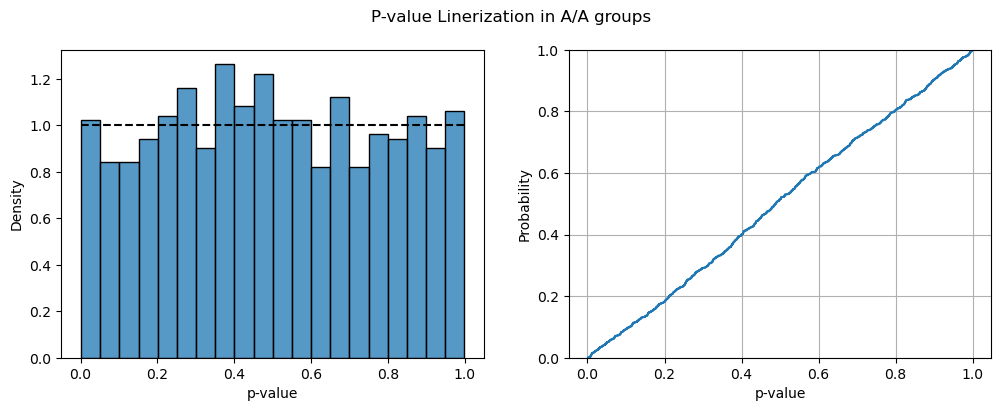

In [27]:
plot_pvalue_ecdf(list_pvalue, title='P-value Linerization in A/A groups')
# Общее количество элементов в списке
total_elements = len(list_pvalue)

# Количество элементов, которые меньше 0.05
elements_less_than_0_05 = sum(p < 0.05 for p in list_pvalue)

print("Общее количество элементов:", total_elements)
print("Количество элементов меньше 0.05:", elements_less_than_0_05)
print("Доля отвергающих равенство средних:", elements_less_than_0_05/total_elements)

In [28]:
data = pd.read_csv("duration_ab.csv")
data

,Unnamed: 0,user_id,group,visit_id,visit_duration
0,0,AOXLT0,a,76v7fwlgmxa73cx08zvh,125.0
1,1,AOXLT0,a,dse16a8xow680xn4ly3o,115.0
2,2,AOXLT0,a,ei17obrkatjb0uglqglr,117.0
3,3,AOXLT0,a,cp9aczsn0zd8a7u9qoel,115.0
4,4,AOXLT0,a,t421ljy1eg7qpdx3dask,123.0
...,...,...,...,...,...
11930,5960,OUFK5V,b,r71fow7gm2hhonw94w8o,124.0
11931,5961,OUFK5V,b,qkl3b7ziw9p3vhuon62n,110.0
11932,5962,OUFK5V,b,c0iv57jkc2q60bas3eoz,130.0
11933,5963,OUFK5V,b,tsz0bo4a6n3lb243kenw,92.0


In [29]:
#проверка
data.isna().sum()


Unnamed: 0        0
user_id           0
group             0
visit_id          0
visit_duration    0
dtype: int64

In [30]:
data['user_id'][data['group'] == 'a'].nunique()

1000

In [31]:
data['user_id'][data['group'] == 'b'].nunique()

1000

In [32]:
# Разделение на группы
first_group_df = data[data['group'] == 'a']
second_group_df = data[data['group'] == 'b']

# Группировка и агрегация
first_group_series = first_group_df.groupby('user_id')['visit_duration'].apply(np.array)
second_group_series = second_group_df.groupby('user_id')['visit_duration'].apply(np.array)

# Преобразование в списки
first_group_arrays = first_group_series.tolist()
second_group_arrays = second_group_series.tolist()

list_pvalue = []

for _ in tqdm_notebook(range(1000)):
    a = random.sample(first_group_arrays, 100)
    b = random.sample(second_group_arrays, 100)
    pvalue, delta = check_linearization(a, b)
    list_pvalue.append(pvalue)

  0%|          | 0/1000 [00:00<?, ?it/s]

Общее количество элементов: 1000
Количество элементов меньше 0.05: 90
Доля отвергающих равенство средних: 0.09


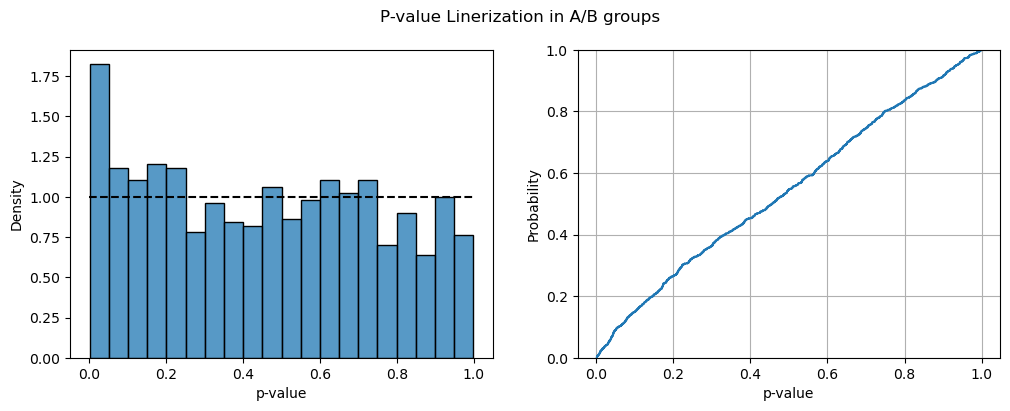

In [33]:
plot_pvalue_ecdf(list_pvalue, title='P-value Linerization in A/B groups')
# Общее количество элементов в списке
total_elements = len(list_pvalue)

# Количество элементов, которые меньше 0.05
elements_less_than_0_05 = sum(p < 0.05 for p in list_pvalue)

print("Общее количество элементов:", total_elements)
print("Количество элементов меньше 0.05:", elements_less_than_0_05)
print("Доля отвергающих равенство средних:", elements_less_than_0_05/total_elements)

In [34]:
# Загрузка исторических данных
data_pre_experiment = pd.read_csv("duration_aa.csv")

# Группировка и агрегация исторических данных
first_group_pre = data_pre_experiment[data_pre_experiment['group'] == 'first'].groupby('user_id')['visit_duration'].apply(np.array).tolist()
second_group_pre = data_pre_experiment[data_pre_experiment['group'] == 'second'].groupby('user_id')['visit_duration'].apply(np.array).tolist()

# Вычисление общего среднего для исторических данных
mean_pre = np.mean([np.mean(arr) for arr in first_group_pre + second_group_pre])

def apply_cuped(a, b, mean_pre):
    """
    Применение CUPED к экспериментальным данным.
    a, b: список массивов длительностей сессий для двух групп
    mean_pre: среднее значение предэкспериментальных данных
    """
    # корректируем каждый элемент массива
    a_corrected = [arr - mean_pre for sublist in a for arr in sublist]
    b_corrected = [arr - mean_pre for sublist in b for arr in sublist]

    # Пересчет средних значений после применения CUPED и выполнение t-теста
    _, pvalue = stats.ttest_ind(a_corrected, b_corrected)
    delta = np.mean(b_corrected) - np.mean(a_corrected)

    return pvalue, delta

list_pvalue = []
for _ in tqdm_notebook(range(1000)):
    a_sample = random.sample(first_group_arrays, 100)
    b_sample = random.sample(second_group_arrays, 100)
    pvalue, delta = apply_cuped(a_sample, b_sample, mean_pre)
    list_pvalue.append(pvalue)

  0%|          | 0/1000 [00:00<?, ?it/s]

Общее количество элементов: 1000
Количество элементов меньше 0.05: 471
Доля отвергающих равенство средних: 0.471


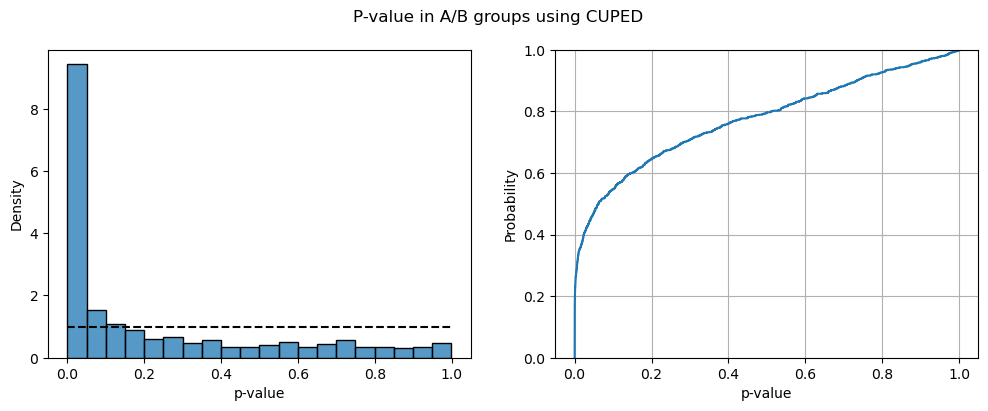

In [35]:
plot_pvalue_ecdf(list_pvalue, title='P-value in A/B groups using CUPED')
# Общее количество элементов в списке
total_elements = len(list_pvalue)

# Количество элементов, которые меньше 0.05
elements_less_than_0_05 = sum(p < 0.05 for p in list_pvalue)

print("Общее количество элементов:", total_elements)
print("Количество элементов меньше 0.05:", elements_less_than_0_05)
print("Доля отвергающих равенство средних:", elements_less_than_0_05/total_elements)

### Задача 4. Последовательное тестирование (3 балла)

Сгенерируйте две контрольные выборки и одну тестовую (с эффектом). Проведите последовательные АА-тесты и АБ-тесты по следующей схеме:

1. Попробуйте использовать t-test. Начните с 1 наблюдения в группах и последовательно добавлять по одному в каждую. Проследите, как меняется О1Р, О2Р.

2. Самостоятельно реализуйте **SPRT-тест Вальда** и проделайте ту же процедуру с ним. Что теперь происходит с О1Р и О2Р? Почему?

In [36]:
# Генерация данных
sample_control = np.random.normal(0, 5, 1000)
sample_treatment = np.random.normal(0, 5, 1000)
sample_treatment_effect = sample_control + np.random.normal(1, 5, 1000)

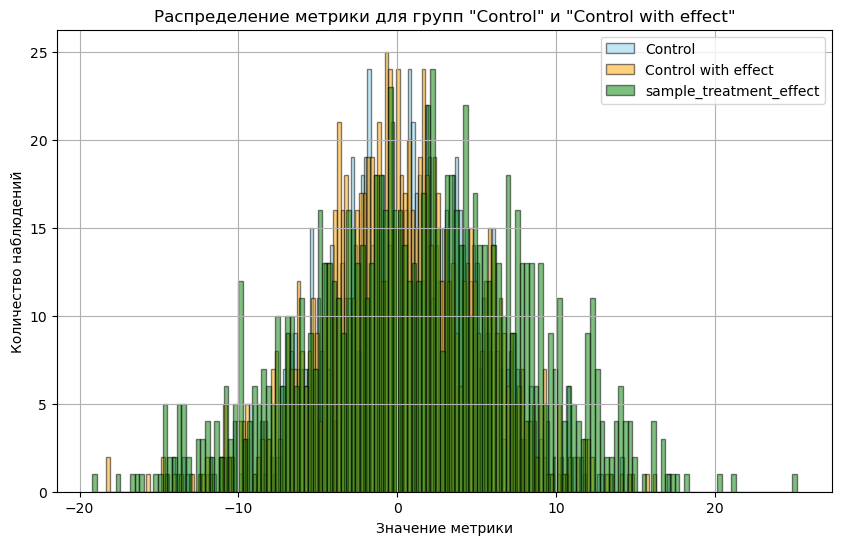

In [37]:
# Строим гистограмму для метрик обеих групп
plt.figure(figsize=(10, 6))

# Гистограмма для группы 'sample_control'
plt.hist(sample_control, bins=150, color='skyblue', edgecolor='black', alpha=0.5, label='Control')

# Гистограмма для группы 'sample_treatment'
plt.hist(sample_treatment, bins=150, color='orange', edgecolor='black', alpha=0.5, label='Control with effect')

# Гистограмма для группы 'treatment'
plt.hist(sample_treatment_effect, bins=150, color='green', edgecolor='black', alpha=0.5, label='sample_treatment_effect')

plt.title('Распределение метрики для групп "Control" и "Control with effect"')
plt.xlabel('Значение метрики')
plt.ylabel('Количество наблюдений')
plt.legend()
plt.grid(True)
plt.show()

  0%|          | 0/1000 [00:00<?, ?it/s]

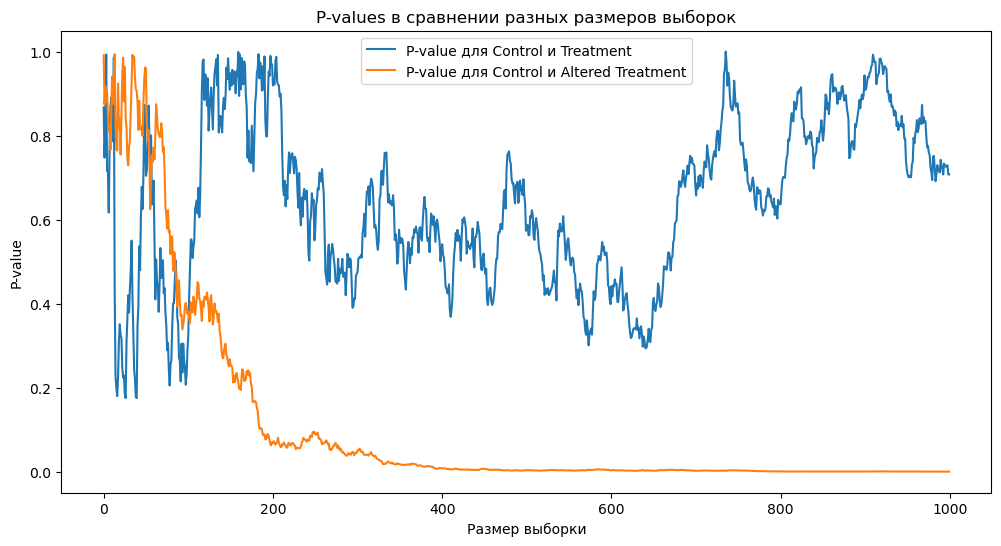

In [38]:
# Инициализация счетчиков и списков для сохранения результатов
alpha_threshold = 0.05
false_positive_rate = []
power_rate = []
p_value_control = []
p_value_treatment = []
rejections_control = 0
rejections_treatment = 0

# Анализ данных
for sample_size in tqdm_notebook(range(2, 1002)):
    subsample_control = sample_control[:sample_size]
    subsample_treatment = sample_treatment[:sample_size]
    subsample_treatment_effect = sample_treatment_effect[:sample_size]

    # Выполнение t-тестов
    _, p_control_vs_treatment = stats.ttest_ind(subsample_control, subsample_treatment)
    _, p_control_vs_treatment_effect = stats.ttest_ind(subsample_control, subsample_treatment_effect)

    # Добавление p-значений в список для отображения
    p_value_control.append(p_control_vs_treatment)
    p_value_treatment.append(p_control_vs_treatment_effect)

    # Подсчет количества ошибок первого рода и мощности
    if p_control_vs_treatment < alpha_threshold:
        rejections_control += 1
    if p_control_vs_treatment_effect > alpha_threshold:
        rejections_treatment += 1

    # Расчет текущих значений False Positive Rate и Power
    false_positive_rate.append(rejections_control / sample_size)
    power_rate.append(rejections_treatment / sample_size)

# Визуализация результатов
plt.figure(figsize=[12, 6])
plt.plot(p_value_control, label="P-value для Control и Treatment")
plt.plot(p_value_treatment, label="P-value для Control и Altered Treatment")
plt.title("P-values в сравнении разных размеров выборок")
plt.xlabel('Размер выборки')
plt.ylabel('P-value')
plt.legend()
plt.show()

  0%|          | 0/998 [00:00<?, ?it/s]

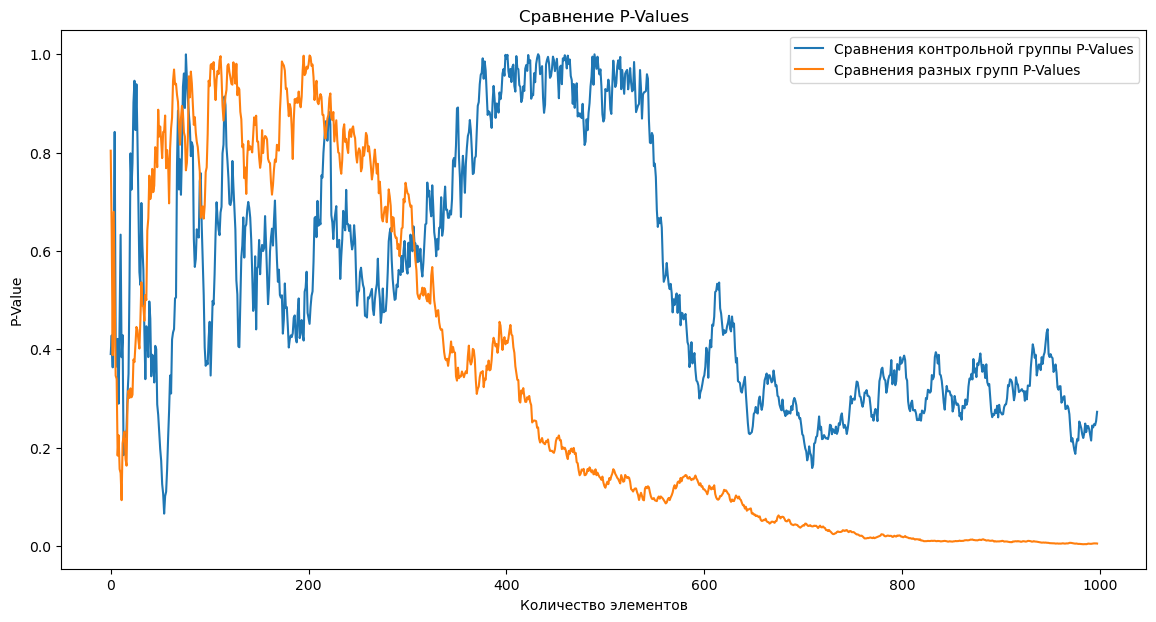

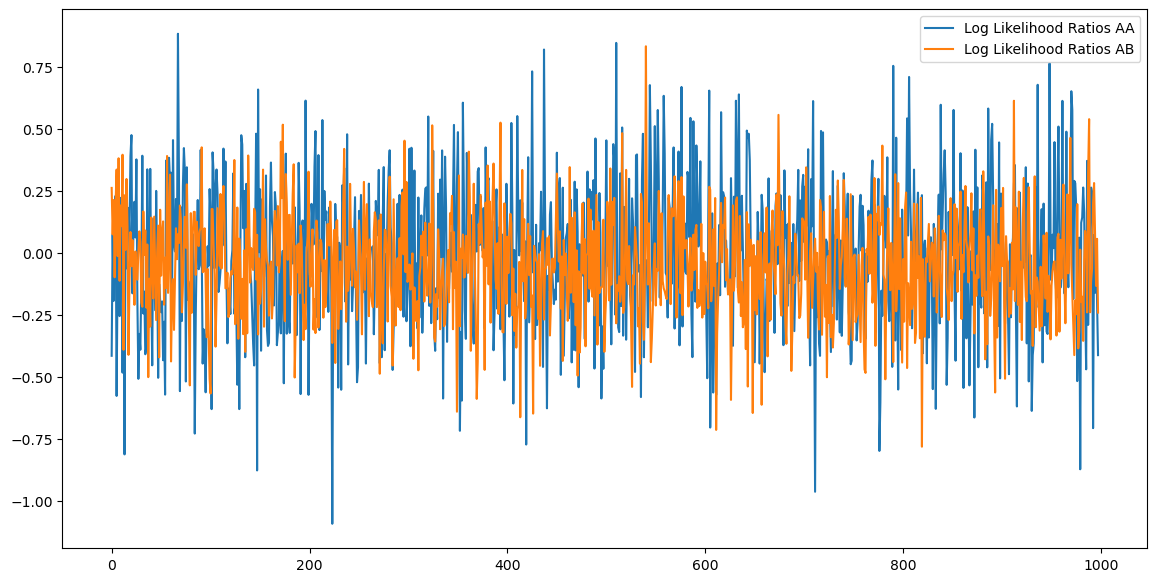

для t-test, примерно нужно +/- 392 элементов в выборке.


In [50]:
# Функция для вычисления отношения правдоподобия логарифма
def calculate_log_likelihood(difference, baseline_mean, alternative_mean, standard_deviation):
    ratio = np.log(
        stats.norm.pdf(difference, alternative_mean, standard_deviation) /
        stats.norm.pdf(difference, baseline_mean, standard_deviation)
    )
    return ratio

# Установка уровня значимости и мощности теста
significance_level = 0.05
power_level = 0.2

# Инициализация счетчиков и списков для хранения результатов
false_positive_counter = 0
true_negative_counter = 0
sprt_false_positives = 0
sprt_true_negatives = 0
type1_error_rates = []
type2_error_rates = []
traditional_pvalues = []
experimental_pvalues = []
log_likelihoods_AA = []
log_likelihoods_AB = []
sprt_type1_rates = []
sprt_type2_rates = []
lower_threshold = np.log(power_level / (1 - significance_level))
upper_threshold = np.log((1 - power_level) / significance_level)

# Параметры нормального распределения для генерации выборок
baseline_mean = 0
altered_mean = 1
deviation = 5

# Размер выборки
sample_size = 1000
baseline_sample = np.random.normal(baseline_mean, deviation, sample_size)
comparison_sample = np.random.normal(baseline_mean, deviation, sample_size)
affected_sample = baseline_sample + np.random.normal(altered_mean, deviation, sample_size)

# Итерация через подвыборки различного размера и расчет статистик
for sample_count in tqdm_notebook(range(2, sample_size)):
    baseline_subset = baseline_sample[:sample_count]
    comparison_subset = comparison_sample[:sample_count]
    affected_subset = affected_sample[:sample_count]
    _, p_val_control = stats.ttest_ind(baseline_subset, comparison_subset)
    _, p_val_affected = stats.ttest_ind(baseline_subset, affected_subset)
    traditional_pvalues.append(p_val_control)
    experimental_pvalues.append(p_val_affected)

    # Учет ошибок первого и второго рода
    if p_val_control < significance_level:
        false_positive_counter += 1
    if p_val_affected > significance_level:
        true_negative_counter += 1
    type1_error_rates.append(false_positive_counter / sample_count)
    type2_error_rates.append(true_negative_counter / sample_count)

    # Расчет отношений правдоподобия для последних наблюдений
    log_lr_AA = calculate_log_likelihood(baseline_subset[-1] - comparison_subset[-1], baseline_mean, altered_mean, deviation)
    log_lr_AB = calculate_log_likelihood(baseline_subset[-1] - affected_subset[-1], baseline_mean, altered_mean, deviation)

    # Учет ошибок первого и второго рода для SPRT
    if log_lr_AA >= upper_threshold:
        sprt_false_positives += 1
    if log_lr_AB <= lower_threshold:
        sprt_true_negatives += 1

    # Сохранение отношений правдоподобия и ошибок первого и второго рода для SPRT
    log_likelihoods_AA.append(log_lr_AA)
    log_likelihoods_AB.append(log_lr_AB)
    sprt_type1_rates.append(sprt_false_positives / sample_count)
    sprt_type2_rates.append(sprt_true_negatives / sample_count)

# Визуализация результатов
plt.figure(figsize=(14, 7))
plt.plot(traditional_pvalues, label="Сравнения контрольной группы P-Values")
plt.plot(experimental_pvalues, label="Сравнения разных групп P-Values")
plt.title("Сравнение P-Values")
plt.xlabel("Количество элементов")
plt.ylabel("P-Value")
plt.legend()
plt.show()

plt.figure(figsize=(14, 7))
plt.plot(log_likelihoods_AA, label="Log Likelihood Ratios AA")
plt.plot(log_likelihoods_AB, label="Log Likelihood Ratios AB")
plt.legend()
plt.show()

# Вывод информации о необходимом количестве элементов в выборке для t-test
print(f'для t-test, примерно нужно +/-', round(2*7.849* ((deviation / altered_mean)**2)), 'элементов в выборке.')

### Задача 5. Бонус от лектора (5 баллов)

_3 балла за выполнение __всех__ пунктов 1-5. +2 балла за пункт 6, при условии, что пункты 1-5 выполнены._

1. Реализуйте mSPRT, предполагая, что функция правдободобия имеет нормальное распределение 
2. Выведите теоретический вид статистики $\Lambda_n$ для нормального распределения 
3. Постройте распределение времени остановки для mSPRT и распределение p-value на А/А тесте 
4. Сделайте то же самое, но для синтетического А/В (добавьте искуственно эффект). Опишите, что поменялось 
5. Сравните mSPRT с классическим t-test
6. Замените расчет интеграла  $\Lambda_n$ на численное приближение расчета. Сравните результаты по пункту 3 и 4

In [42]:
# Параметры
mu_0 = 0.0
mu_1 = 0.5
sigma = 1.0
n = 10000
alpha = 0.05
beta = 0.2
a = np.log(beta / (1 - alpha))  # Нижний порог
b = np.log((1 - beta) / alpha)  # Верхний порог

# Функция для mSPRT
def msprt(mu_change=0.0):
    observations = np.random.normal(mu_0 + mu_change, sigma, n)
    llr = 0
    for i, x in enumerate(observations, start=1):
        llr += ((x - mu_0)**2 - (x - mu_1)**2) / (2 * sigma**2)
        if llr <= 2 * sigma**2 * a:
            return i, 'H0', llr
        elif llr >= 2 * sigma**2 * b:
            return i, 'H1', llr
    return n, 'No decision', llr

# Вызов функции mSPRT и вывод результата
result = msprt(mu_change=0.5)
print(f"Время остановки: {result[0]}, Решение: {result[1]}, Финальное значение Λn: {result[2]:.2f}")

Время остановки: 114, Решение: H1, Финальное значение Λn: 6.21


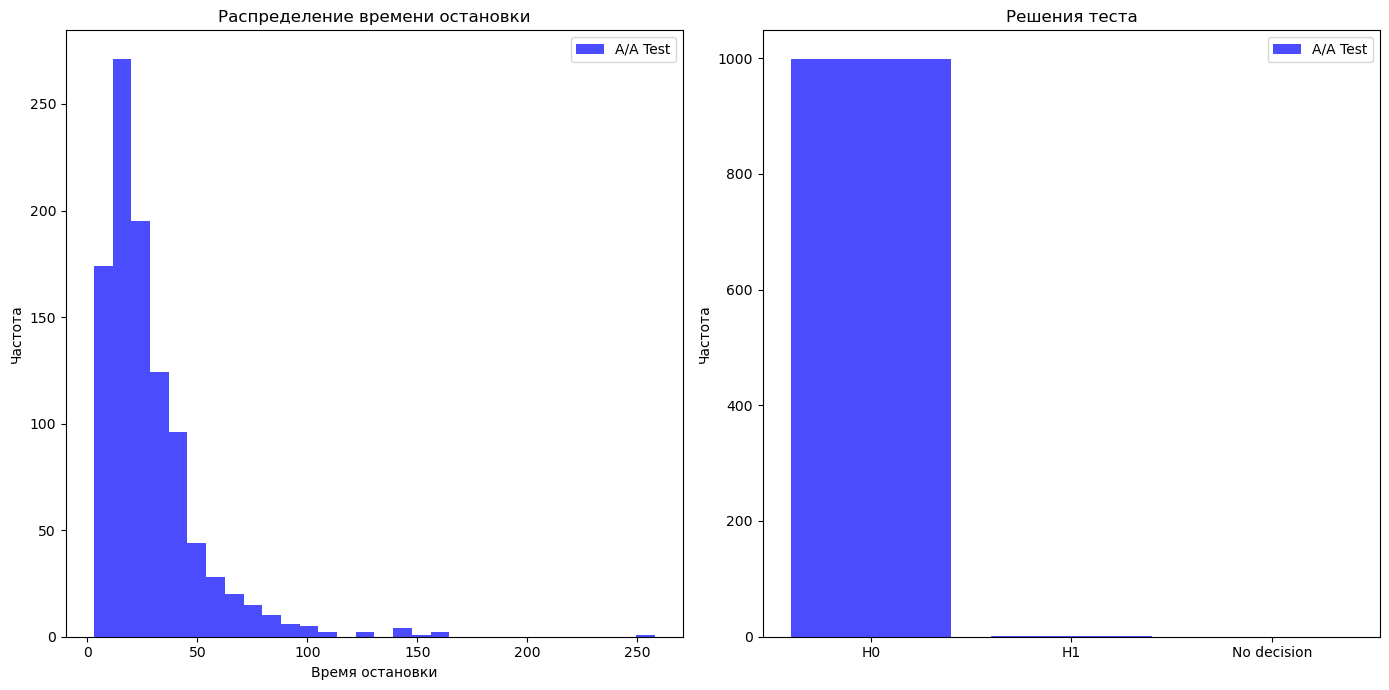

In [45]:
# Симуляция распределения времени остановки и p-value для А/А и А/В теста
stop_times_aa, decisions_aa, llr_values_aa = zip(*(msprt() for _ in range(1000)))

# Вывод результатов
plt.figure(figsize=(14, 7))
plt.subplot(1, 2, 1)
plt.hist(stop_times_aa, bins=30, color='blue', alpha=0.7, label='A/A Test')
plt.title('Распределение времени остановки')
plt.xlabel('Время остановки')
plt.ylabel('Частота')
plt.legend()

plt.subplot(1, 2, 2)
plt.bar(['H0', 'H1', 'No decision'], [decisions_aa.count('H0'), decisions_aa.count('H1'), decisions_aa.count('No decision')], color='blue', alpha=0.7, label='A/A Test')

plt.title('Решения теста')
plt.ylabel('Частота')
plt.legend()

plt.tight_layout()
plt.show()

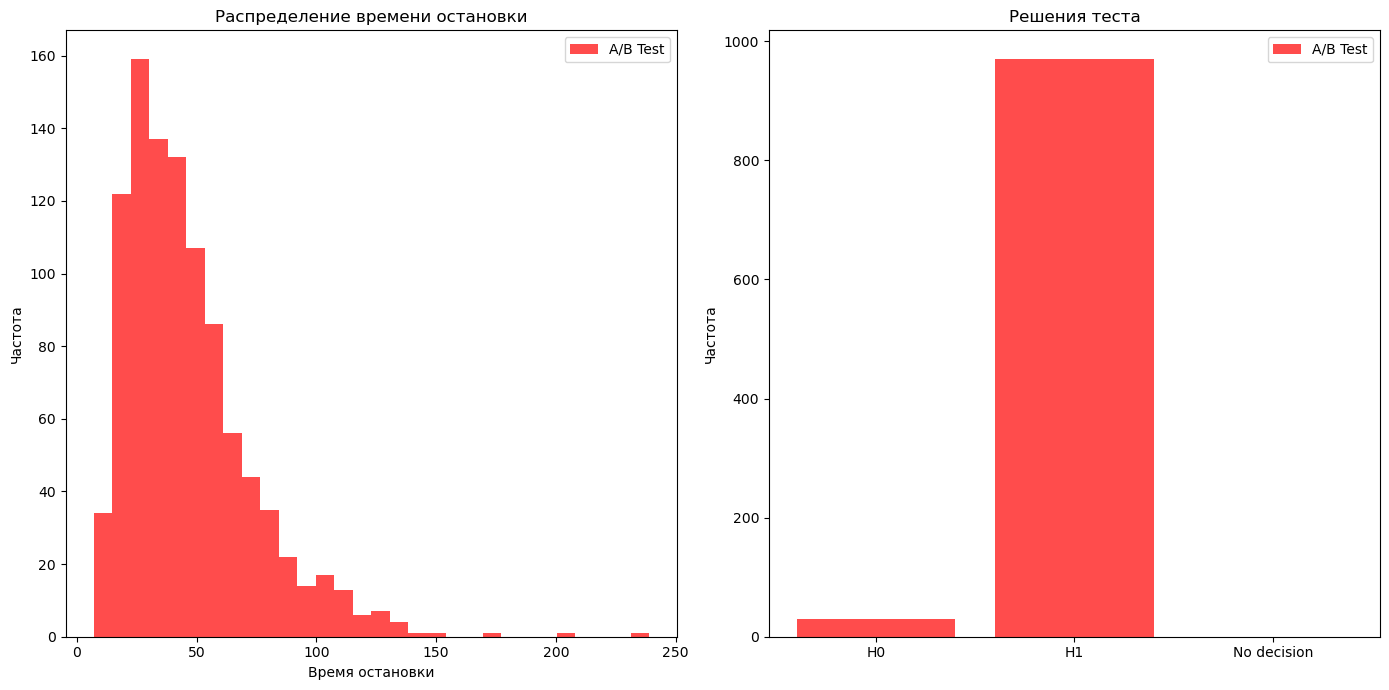

In [48]:
stop_times_ab, decisions_ab, llr_values_ab = zip(*(msprt(mu_change=0.5) for _ in range(1000)))

# Вывод результатов
plt.figure(figsize=(14, 7))
plt.subplot(1, 2, 1)
plt.hist(stop_times_ab, bins=30, color='red', alpha=0.7, label='A/B Test')
plt.title('Распределение времени остановки')
plt.xlabel('Время остановки')
plt.ylabel('Частота')
plt.legend()

plt.subplot(1, 2, 2)
# Изменение здесь: убран аргумент bottom, чтобы столбцы начинались снизу
plt.bar(['H0', 'H1', 'No decision'], [decisions_ab.count('H0'), decisions_ab.count('H1'), decisions_ab.count('No decision')], color='red', alpha=0.7, label='A/B Test')
plt.title('Решения теста')
plt.ylabel('Частота')
plt.legend()

plt.tight_layout()
plt.show()


В А/А тесте мы ожидаем, что большинство экспериментов не приведет к отклонению нулевой гипотезы (поскольку реального эффекта нет), и время остановки должно быть равномерно распределено, если тест не останавливается рано из-за случайных колебаний.

В А/В тесте с искусственным эффектом мы ожидаем, что большее количество экспериментов приведет к отклонению нулевой гипотезы (поскольку есть реальный эффект), и время остановки может быть меньше, поскольку тест быстрее обнаруживает реальные различия.

In [49]:
# Параметры распределения для генерации данных
mu_control = 0.0  # Среднее контрольной группы
mu_experiment = 0.5  # Среднее экспериментальной группы (искусственный эффект)
sigma = 1.0  # Стандартное отклонение для обеих групп
n = 10000  # Количество наблюдений в каждой группе

# Генерация данных
np.random.seed(42)  # Для воспроизводимости результатов
data_control = np.random.normal(mu_control, sigma, n)
data_experiment = np.random.normal(mu_experiment, sigma, n)

# Применение классического t-теста
t_stat, p_value = stats.ttest_ind(data_control, data_experiment)

# mSPRT
decision = msprt(mu_change=0.5)  # Используем функцию msprt из предыдущего примера

# Вывод результатов
print(f"Классический t-тест: t-статистика = {t_stat:.2f}, p-значение = {p_value:.4f}")
if p_value <= 0.05:
    print("t-test: Нулевая гипотеза отвергнута")
else:
    print("t-test: Нулевая гипотеза принята")

if decision[1] == 'H1':
    print("mSPRT: Нулевая гипотеза отвергнута")
elif decision[1] == 'H0':
    print("mSPRT: Нулевая гипотеза принята")
else:
    print("mSPRT: Решение не принято")

Классический t-тест: t-статистика = -36.38, p-значение = 0.0000
t-test: Нулевая гипотеза отвергнута
mSPRT: Нулевая гипотеза отвергнута
